In [1]:
import pandas as pd
import numpy as np 

from typing import List
from default_vars import UNCERTAINTY_EXPRESSIONS as EXPR_ORDER
from metrics import get_statistics_per_distribution
from utils_histograms import histogram_to_dataframe
from utils_plot import *
from utils_io import read_json

save_fig_kwargs = {
    "base_dir": "../../figures",
    "dpi": 400,
}

### LLM+NV histogram (Figure 5): empirical distribution for all uncertainty expressions

Plot the histograms for the following models:

- `Olmo-7B Instruct`
- `gpt-4o`

In [2]:
def parse_data_for_histogram(data, statistic: str, unc_col: str, expr_order: list):
    data_statistics = get_statistics_per_distribution(data)
    statistic = data_statistics[statistic]
    histogram, statistic_mask = histogram_to_dataframe(data, statistic=statistic, unc_col=unc_col, expr_order=expr_order)
    return histogram, statistic_mask

In [3]:
parse_data_kwargs = dict(
    statistic="max",
    unc_col="uncertainty_expression",
    expr_order=EXPR_ORDER,
)

olmo_data = read_json("../../results/greedy/all/non_verifiable/models-2shot/full__allenai__OLMo-7B-Instruct_normalized.json")
olmo_hist, olmo_stats_mask = parse_data_for_histogram(olmo_data, **parse_data_kwargs)

gptfo_data = read_json("../../results/greedy/all/non_verifiable/models-2shot/gpt-4o-2024-05-13_normalized.json")
gptfo_hist, gptfo_stats_mask = parse_data_for_histogram(gptfo_data, **parse_data_kwargs)


human_data = read_json("../../results/greedy/all/non_verifiable/humans-2shot-filtered/normalized.json")
human_hist, human_stats_mask =parse_data_for_histogram(human_data, **parse_data_kwargs)

**Plotting**

In [4]:
heatmap_default_kwargs =  dict(
    vmin=0, vmax=1, cmap="Blues", linecolor='white', linewidth=0.01,
)

gptfo_heatmap_kwargs = dict(cbar=False)
olmo_heatmap_kwargs = dict(cbar_kws={
             'label': 'Empirical Frequency', # Set the colorbar label
             'orientation': 'horizontal', 
             'shrink': 1,                # Shrink the size of the colorbar
             'aspect': 20,                  # Aspect ratio of the colorbar
             'pad': 0.02,  
        },
)

/tmp/ipykernel_2022766/1516071241.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])
/tmp/ipykernel_2022766/1516071241.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])


Saving figure at ../../figures/all__nv_models_olmo_gpt-4o__normalized__stacked.pdf


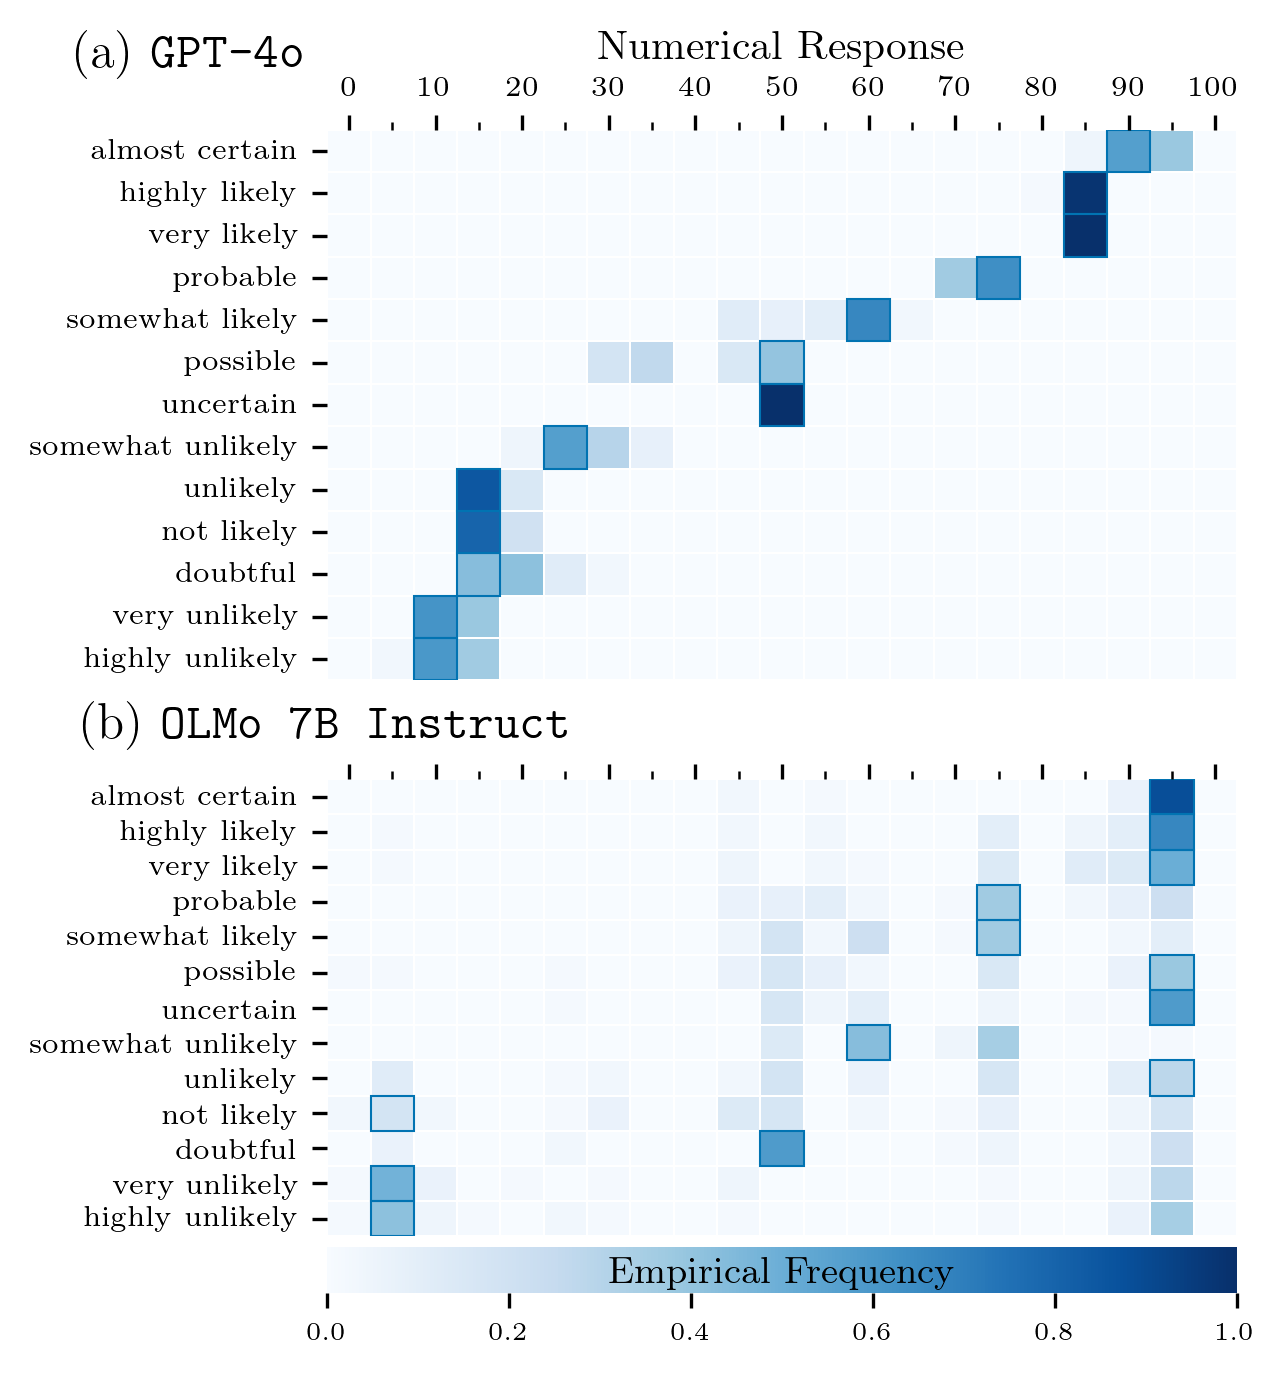

In [5]:
matplotlib.rc('font', family='serif', size=6)

fig, axes= plt.subplots(2, 1, sharey=True, sharex=True, figsize=(COL_WIDTH, 4), dpi=300)

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 
#                OLMO-7B-INSTRUCT
# 
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
ax=axes[0]
heatmap = sns.heatmap(gptfo_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)

# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(gptfo_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=0.5)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=10)
ax.set_title("(a) \\texttt{GPT-4o}", fontsize=12, y=1, x=-0.15, pad=15)

ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=7)


# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 
#                OLMO-7B-INSTRUCT
# 
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
ax=axes[1]
ax.set_title("(b) \\texttt{OLMo 7B Instruct}", fontsize=12, y=1, x=-0, pad=10)

heatmap = sns.heatmap(olmo_hist, ax=ax, **heatmap_default_kwargs, **olmo_heatmap_kwargs)
# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(olmo_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=0.5)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# ax.set_xlabel("Numerical Response", fontsize=10)
# ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True)
ax.tick_params(top=True, bottom=False, labeltop=False, labelbottom=False)

#plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=7)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=7)

# Adjust color bar
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
cbar = heatmap.collections[0].colorbar
# Adjust the label position and font size
cbar.set_label('Empirical Frequency', labelpad=-21, fontsize=9)  # labelpad adjusts location
cbar.ax.tick_params(labelsize=6)#, labelcolor=sns.color_palette()[0])  # Customize font size, color, and rotation

adjust(fig, hspace=0.18)
save_fig(fig, f"all__nv_models_olmo_gpt-4o__normalized__stacked.pdf", **save_fig_kwargs)

## Poster (Results)

In [64]:
save_fig_kwargs

{'base_dir': '../../figures', 'dpi': 400}

## Poster

In [6]:
data = read_json("../../results/greedy/all/non_verifiable/humans-2shot-filtered/normalized.json")
statistic="max"
unc_col="uncertainty_expression"
expr_order=EXPR_ORDER

data_statistics = get_statistics_per_distribution(data)
statistic = data_statistics[statistic]
histogram, statistic_mask = histogram_to_dataframe(data, statistic=statistic, unc_col=unc_col, expr_order=expr_order)

/tmp/ipykernel_1895486/3414825046.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + human_hist.index.tolist() + [""])
/tmp/ipykernel_1895486/3414825046.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + gptfo_hist.index.tolist() + [""])
/tmp/ipykernel_1895486/3414825046.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])


Saving figure at ../../figures/all__nv_models_human_olmo_gpt-4o__normalized__stacked.png


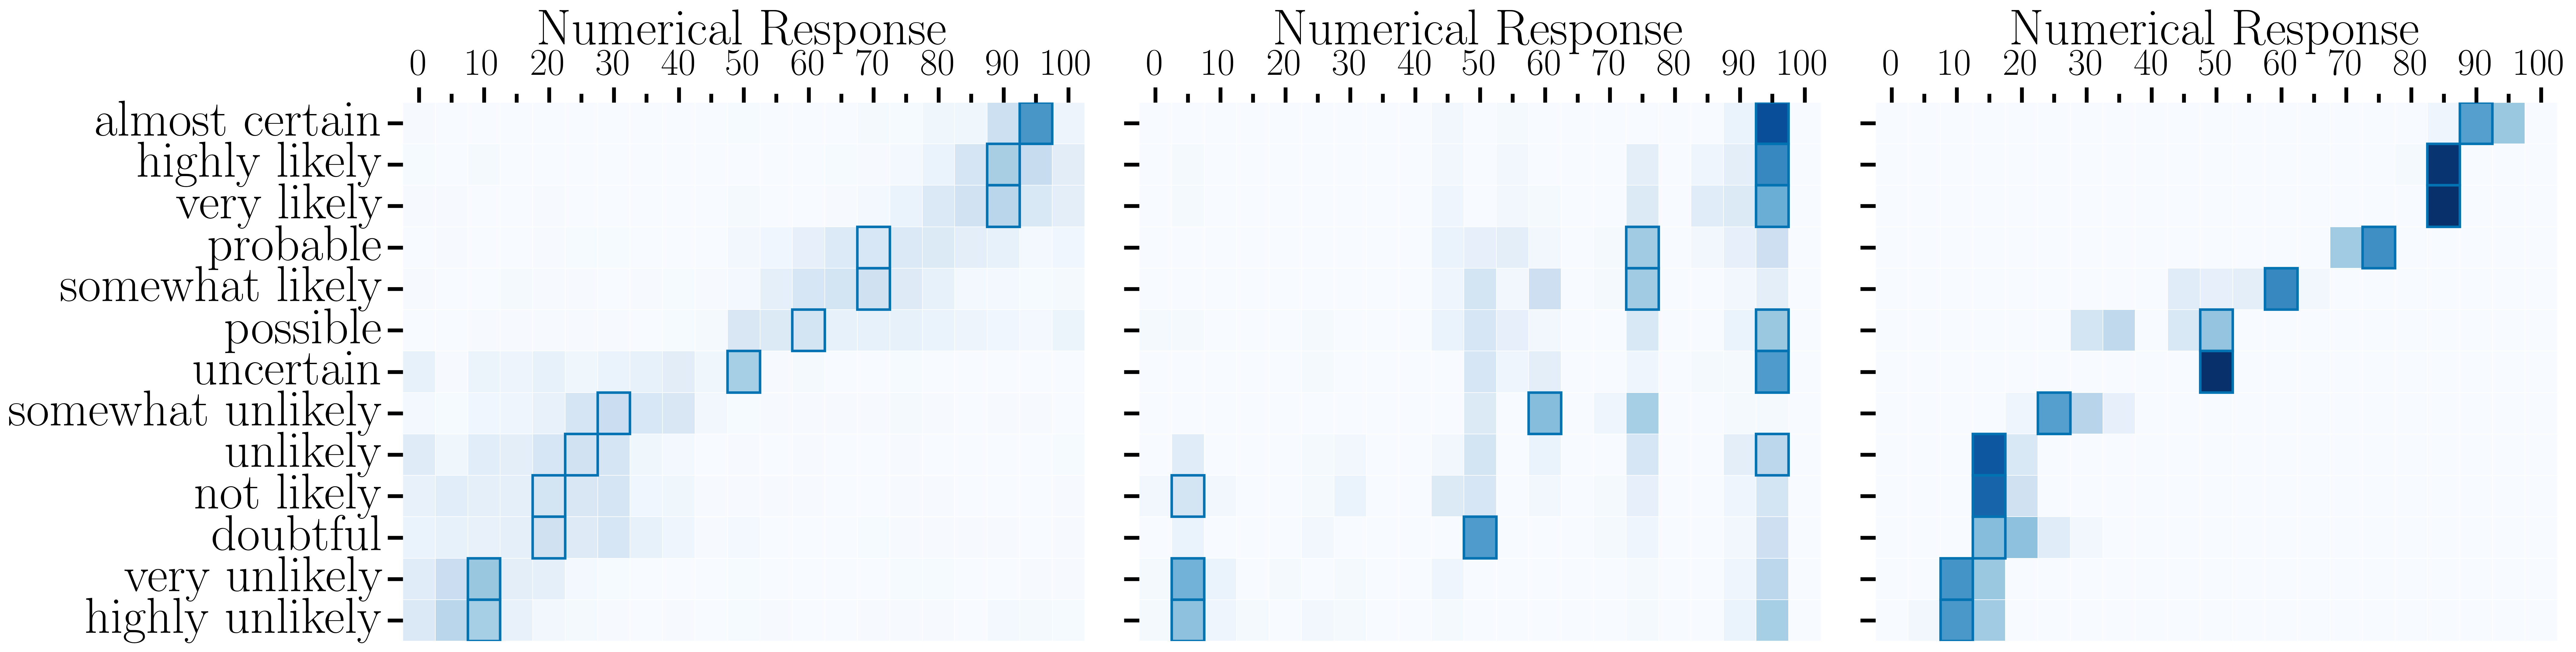

In [76]:
cm = 1/2.54  # centimeters in inches
fig, axes= plt.subplots(1, 3, sharey=True, sharex=True, figsize=(60*cm, 15*cm), dpi=300)


ax=axes[0]
heatmap = sns.heatmap(human_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)

# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(human_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
#ax.set_title("(a) \\texttt{GPT-4o}", fontsize=12, y=1, x=0, pad=15)

ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + human_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)



# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 
#                GPT-4o
# 
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
ax=axes[2]
heatmap = sns.heatmap(gptfo_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)

# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(gptfo_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
#ax.set_title("(a) \\texttt{GPT-4o}", fontsize=12, y=1, x=0, pad=15)

ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + gptfo_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)


# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 
#                OLMO-7B-INSTRUCT
# 
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
ax=axes[1]
#ax.set_title("(b) \\texttt{OLMo 7B Instruct}", fontsize=12, y=1, x=-0, pad=10)

heatmap = sns.heatmap(olmo_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)
# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(olmo_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)


# Adjust color bar
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#cbar = heatmap.collections[0].colorbar
# Adjust the label position and font size
#cbar.set_label('Empirical Frequency', labelpad=-21, fontsize=9)  # labelpad adjusts location
#cbar.ax.tick_params(labelsize=6)#, labelcolor=sns.color_palette()[0])  # Customize font size, color, and rotation

adjust(fig, wspace=0.08)
save_fig(fig, f"all__nv_models_human_olmo_gpt-4o__normalized__stacked.png", **{'base_dir': '../../figures', 'dpi': 400})
# pngs with more than 1600px x 1600px are comrpessed and become blurry...

/tmp/ipykernel_1895486/2440811011.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + human_hist.index.tolist() + [""])
/tmp/ipykernel_1895486/2440811011.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + gptfo_hist.index.tolist() + [""])
/tmp/ipykernel_1895486/2440811011.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])


Saving figure at ../../figures/poster__all__nv_models_human__normalized_1.png


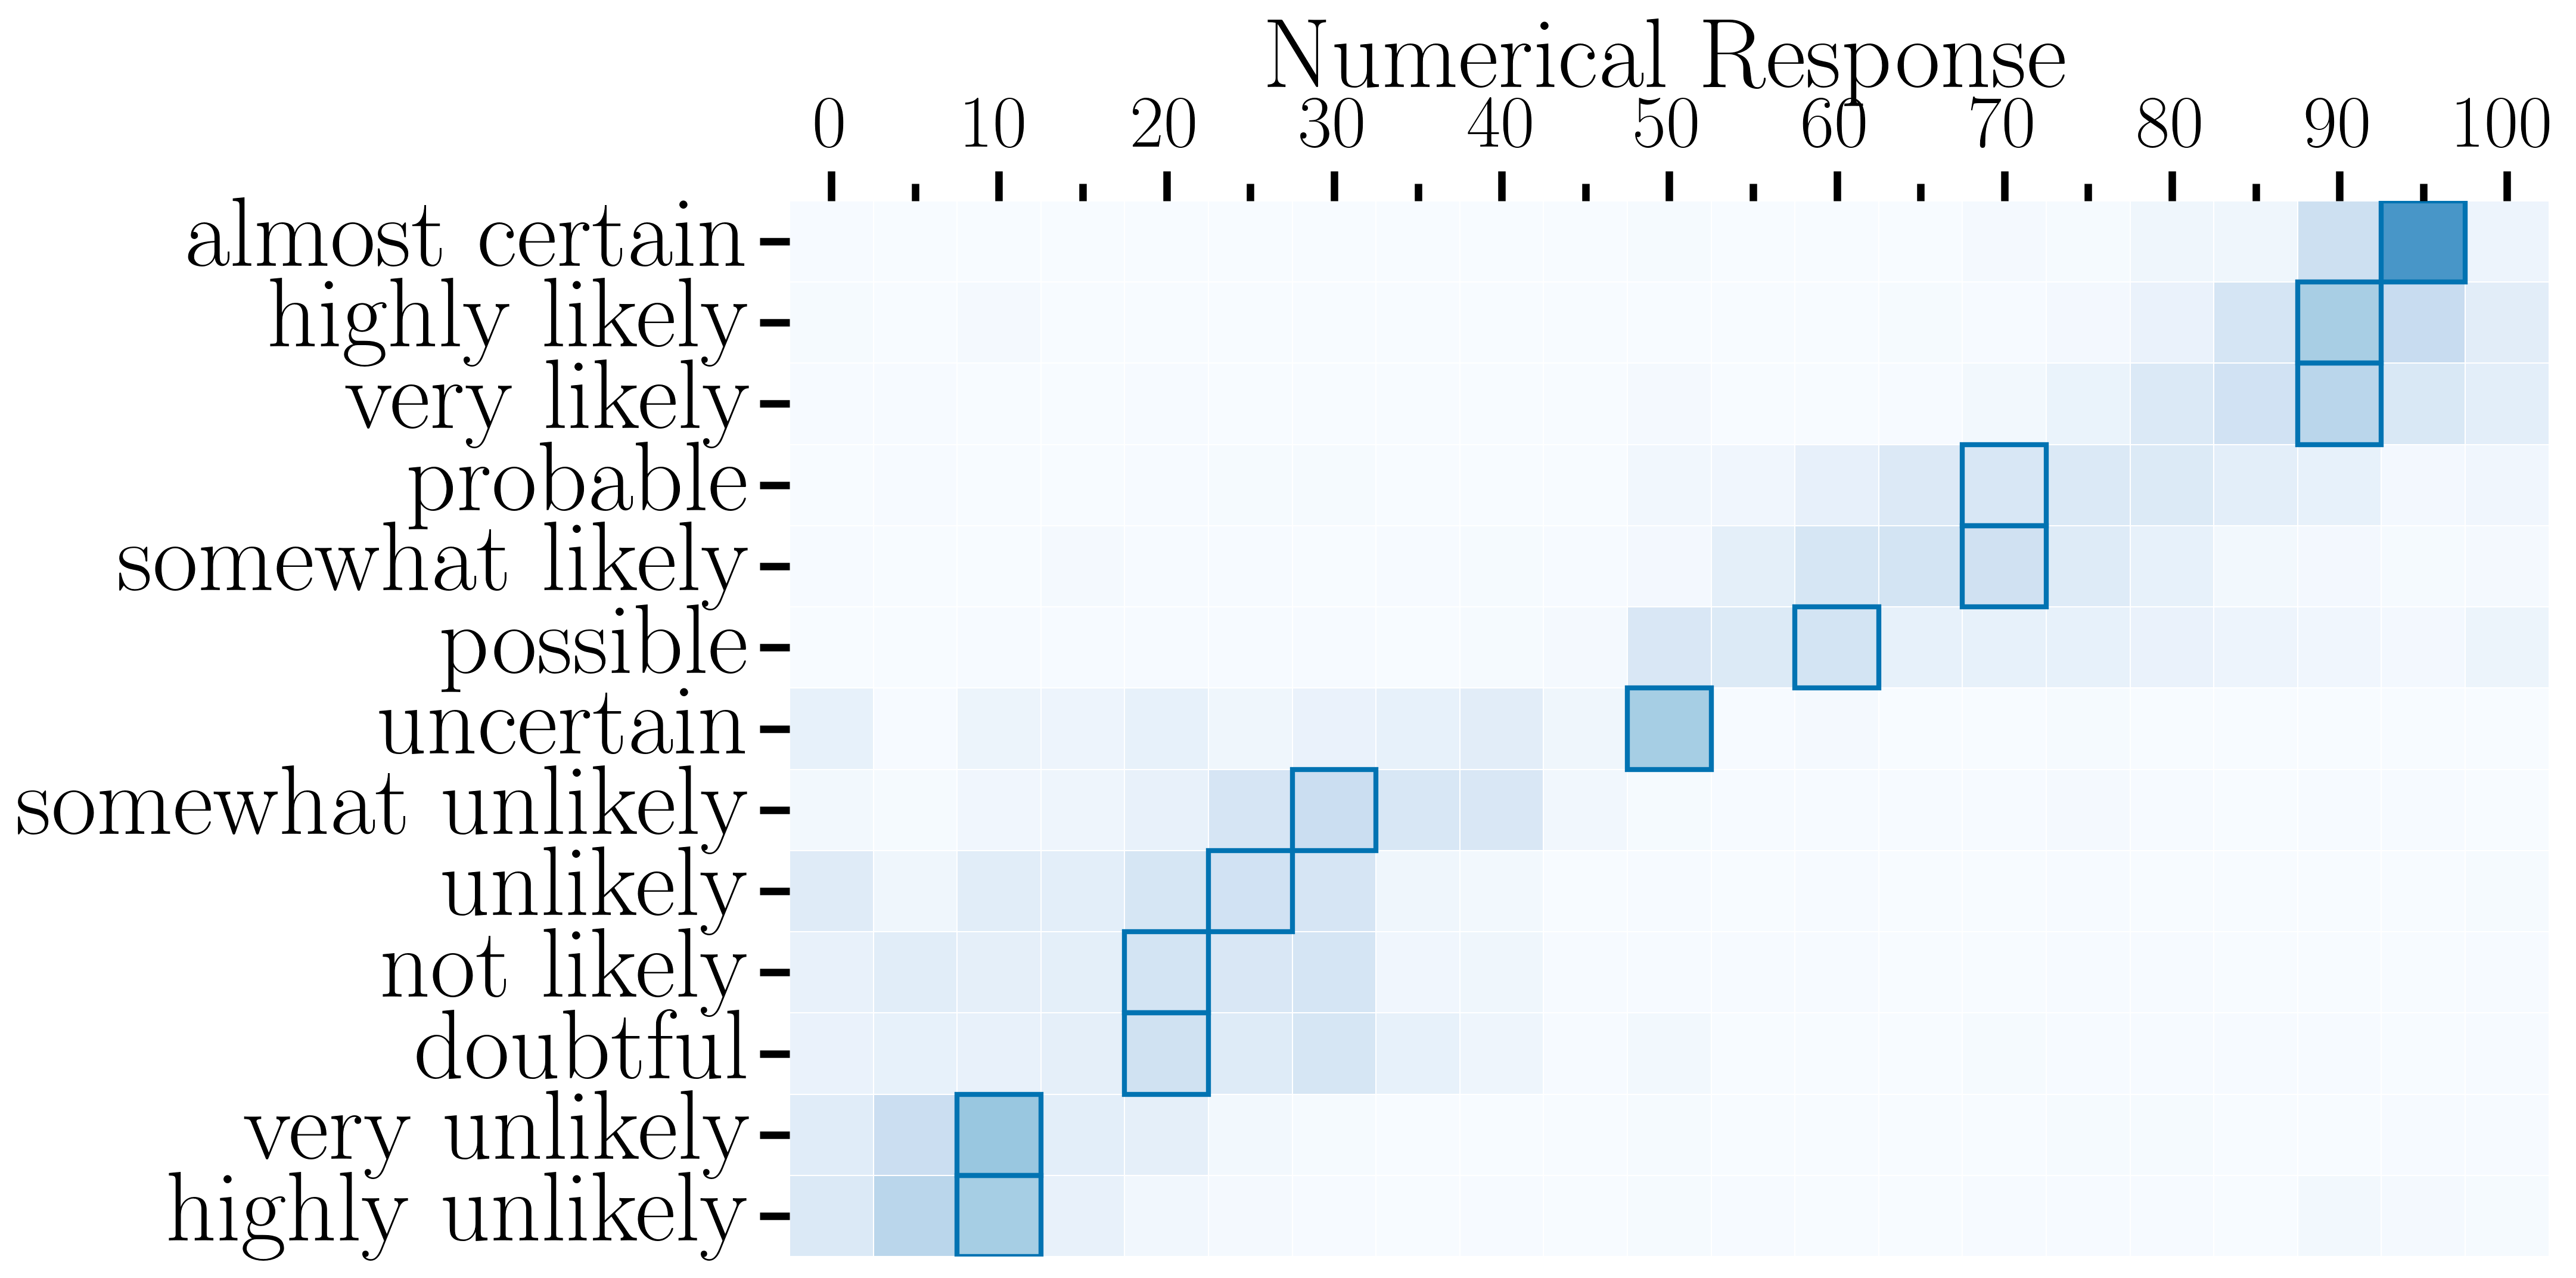

In [84]:
# poster (alternative 2)

cm = 1/2.54  # centimeters in inches
fig, ax= plt.subplots(1, 1, figsize=(25*cm, 15*cm), dpi=300)
heatmap = sns.heatmap(human_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)

# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(human_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
#ax.set_title("(a) \\texttt{GPT-4o}", fontsize=12, y=1, x=0, pad=15)

ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + human_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)



# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 
#                GPT-4o
# 
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
ax=axes[2]
heatmap = sns.heatmap(gptfo_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)

# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(gptfo_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
#ax.set_title("(a) \\texttt{GPT-4o}", fontsize=12, y=1, x=0, pad=15)

ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + gptfo_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)


# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# 
#                OLMO-7B-INSTRUCT
# 
# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
ax=axes[1]
#ax.set_title("(b) \\texttt{OLMo 7B Instruct}", fontsize=12, y=1, x=-0, pad=10)

heatmap = sns.heatmap(olmo_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)
# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(olmo_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)


# Adjust color bar
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#cbar = heatmap.collections[0].colorbar
# Adjust the label position and font size
#cbar.set_label('Empirical Frequency', labelpad=-21, fontsize=9)  # labelpad adjusts location
#cbar.ax.tick_params(labelsize=6)#, labelcolor=sns.color_palette()[0])  # Customize font size, color, and rotation

adjust(fig)
save_fig(fig, f"poster__all__nv_models_human__normalized_1.png", **{'base_dir': '../../figures', 'dpi': 400})
# pngs with more than 1600px x 1600px are comrpessed and become blurry...

/tmp/ipykernel_1895486/352263656.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + gptfo_hist.index.tolist() + [""])


Saving figure at ../../figures/poster__all__nv_models_gpt4o__normalized_3.png


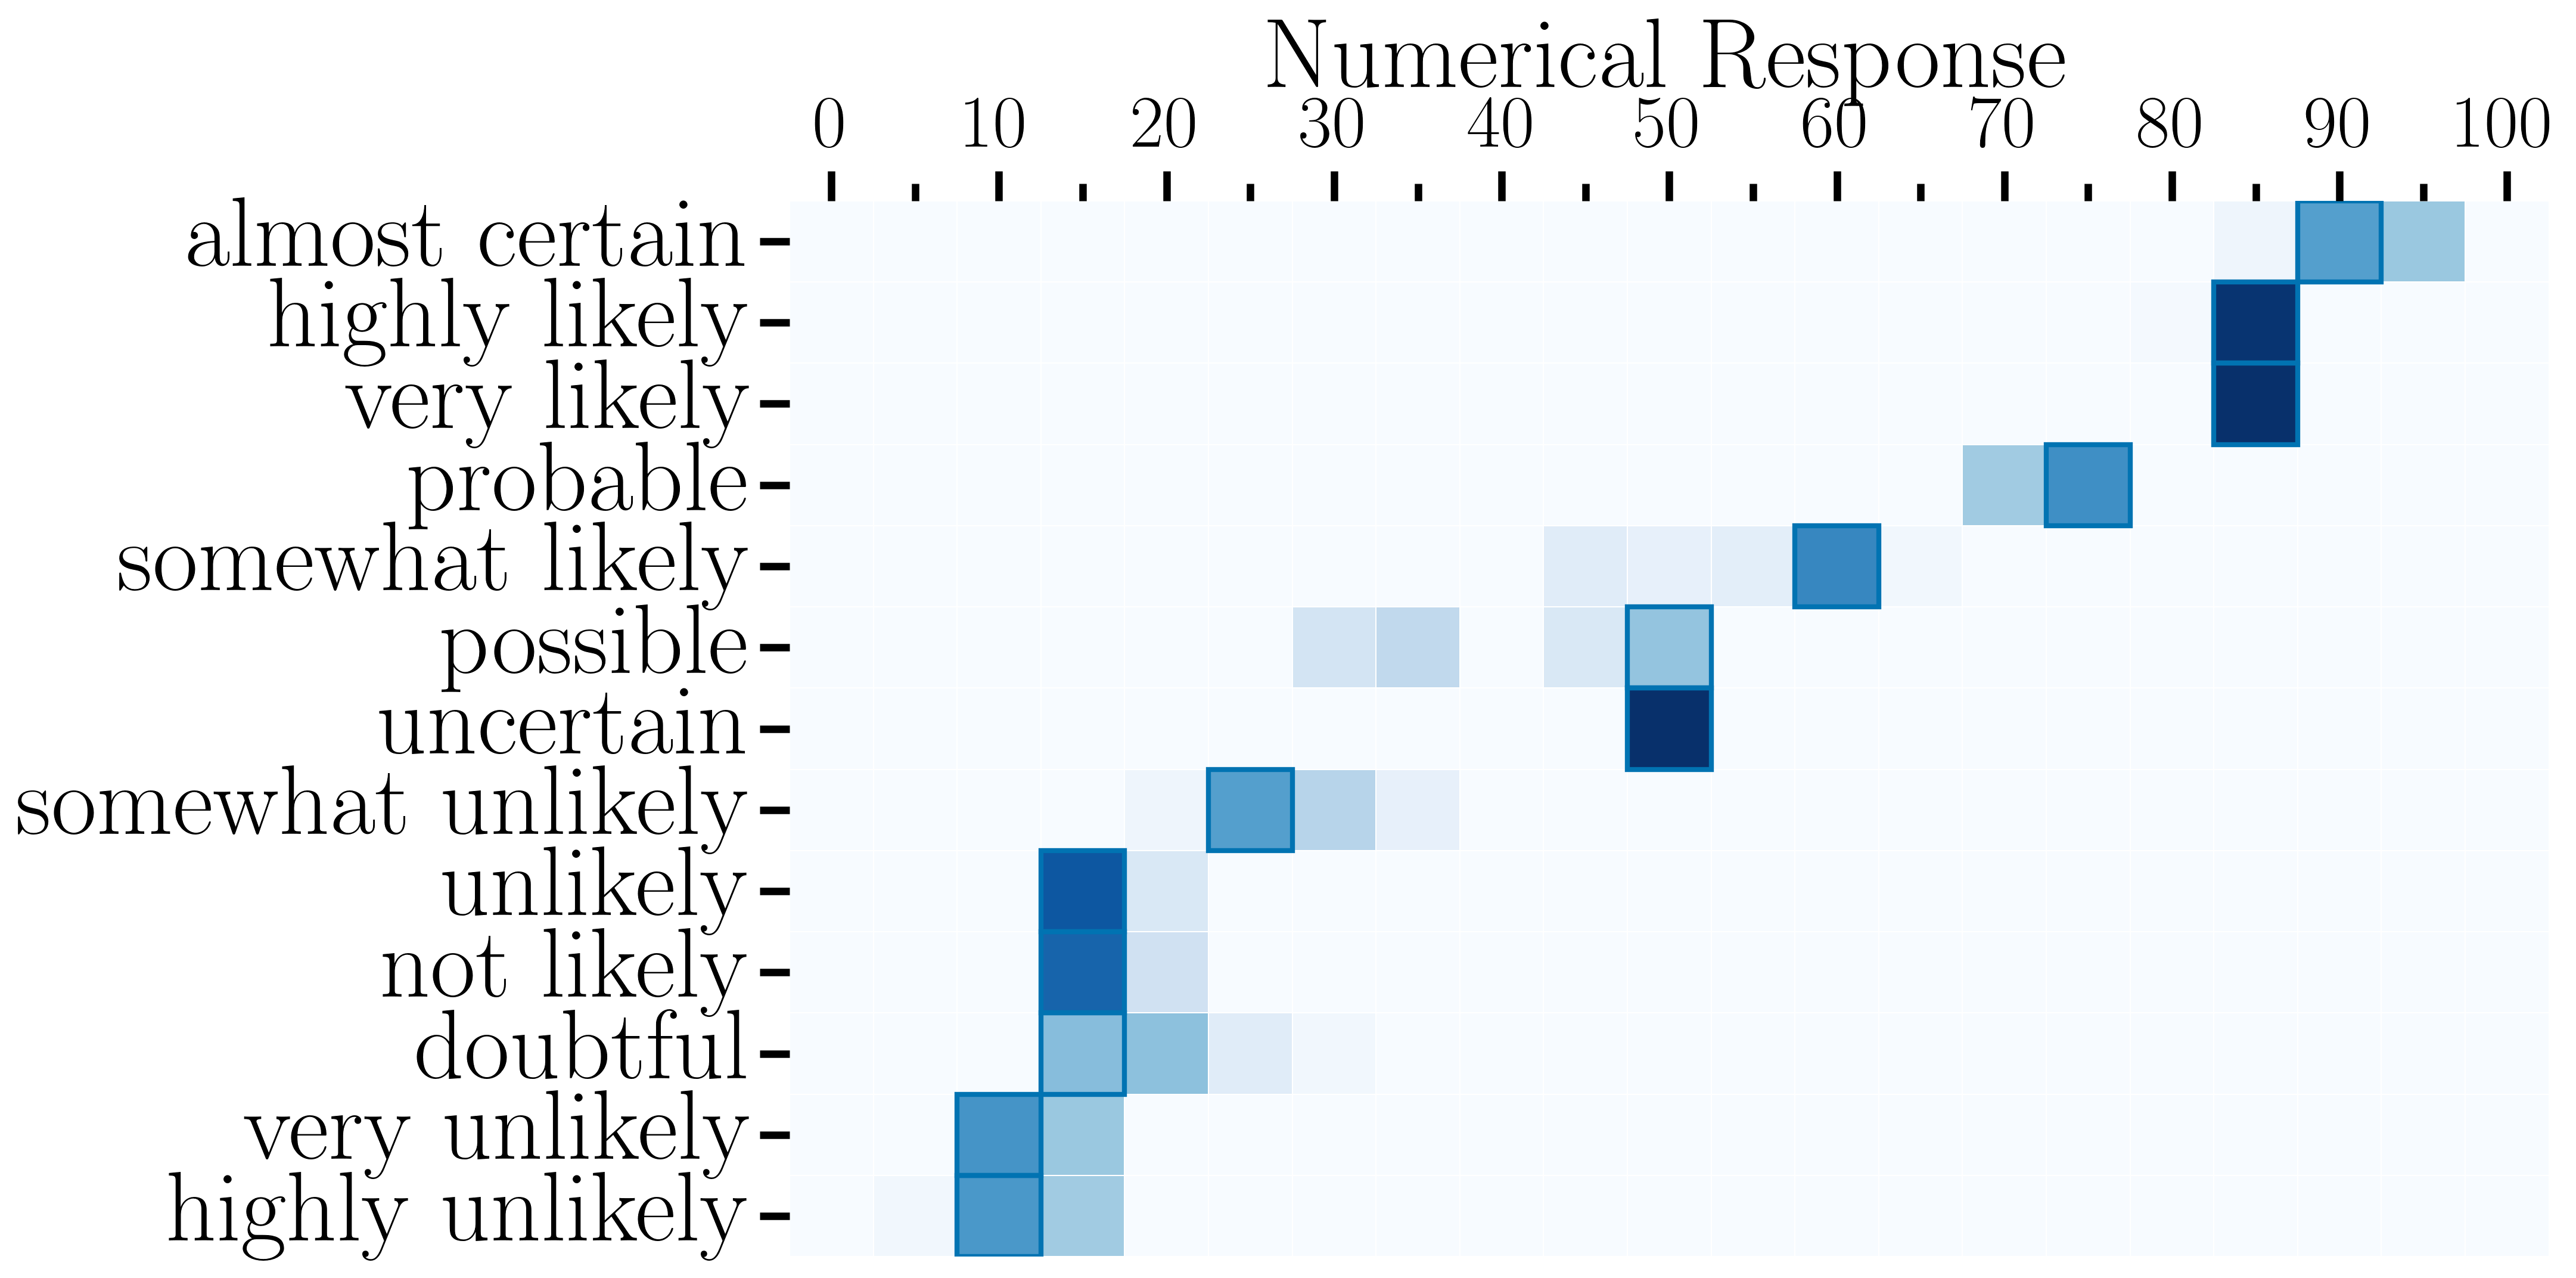

In [85]:
# poster (alternative 2)

cm = 1/2.54  # centimeters in inches
fig, ax= plt.subplots(1, 1, figsize=(25*cm, 15*cm), dpi=300)
heatmap = sns.heatmap(gptfo_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)

# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(gptfo_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
#ax.set_title("(a) \\texttt{GPT-4o}", fontsize=12, y=1, x=0, pad=15)

ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + gptfo_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)

# Adjust color bar
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
#cbar = heatmap.collections[0].colorbar
# Adjust the label position and font size
#cbar.set_label('Empirical Frequency', labelpad=-21, fontsize=9)  # labelpad adjusts location
#cbar.ax.tick_params(labelsize=6)#, labelcolor=sns.color_palette()[0])  # Customize font size, color, and rotation

adjust(fig)
save_fig(fig, f"poster__all__nv_models_gpt4o__normalized_3.png", **{'base_dir': '../../figures', 'dpi': 400})
# pngs with more than 1600px x 1600px are comrpessed and become blurry...

/tmp/ipykernel_1895486/2675327553.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])


Saving figure at ../../figures/poster__all__nv_models_olmo__normalized_2.png


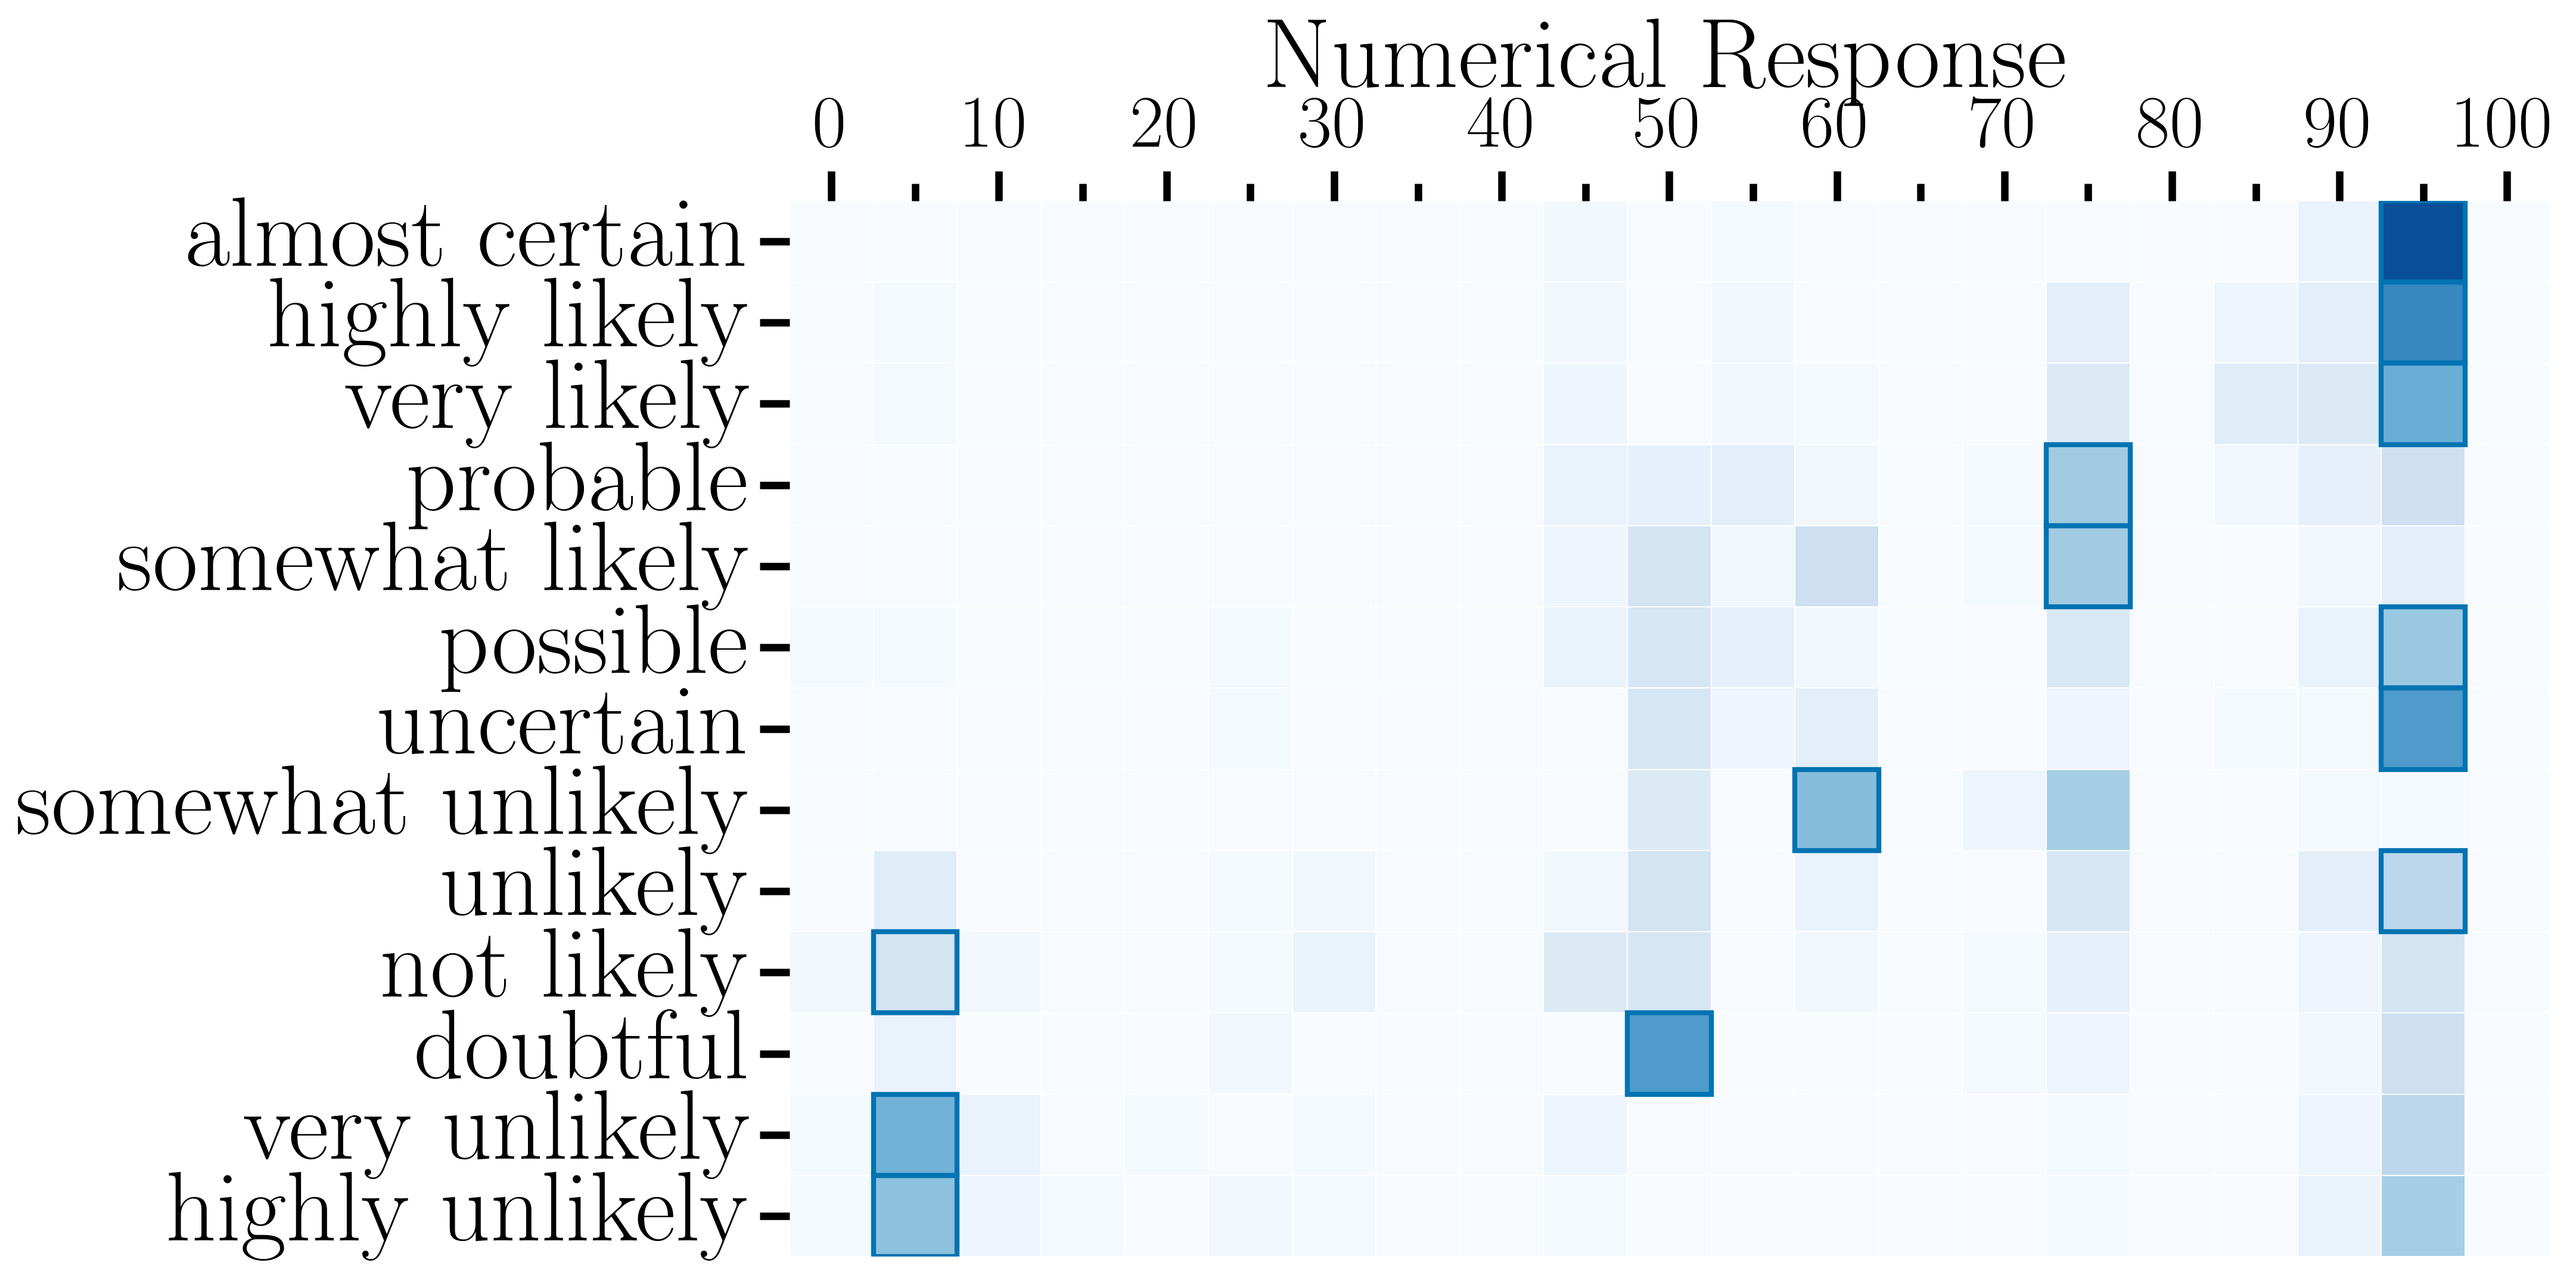

In [86]:
# poster (alternative 2)

cm = 1/2.54  # centimeters in inches
fig, ax= plt.subplots(1, 1, figsize=(25*cm, 15*cm), dpi=300)

heatmap = sns.heatmap(olmo_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)
# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(olmo_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + olmo_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)


adjust(fig)
save_fig(fig, f"poster__all__nv_models_olmo__normalized_2.png", **{'base_dir': '../../figures', 'dpi': 400})
# pngs with more than 1600px x 1600px are comrpessed and become blurry...

### Presentation

In [7]:
parse_data_kwargs = dict(
    statistic="max",
    unc_col="uncertainty_expression",
    expr_order=EXPR_ORDER,
)

gpt4_data = read_json("../../results/greedy/all/non_verifiable/models-2shot/gpt-4-turbo-2024-04-09_normalized.json")
gpt4_hist, gpt4_stats_mask = parse_data_for_histogram(gpt4_data, **parse_data_kwargs)

llama_data = read_json("../../results/greedy/all/non_verifiable/models-2shot/full__meta-llama__Meta-Llama-3-70B-Instruct_normalized.json")
llama_hist, llama_stats_mask = parse_data_for_histogram(llama_data, **parse_data_kwargs)

human_data = read_json("../../results/greedy/all/non_verifiable/humans-2shot-filtered/normalized.json")
human_hist, human_stats_mask =parse_data_for_histogram(human_data, **parse_data_kwargs)

/tmp/ipykernel_2022766/810670213.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + gpt4_hist.index.tolist() + [""])


Saving figure at ../../figures/poster__all__nv_models_gpt4__normalized_2.png


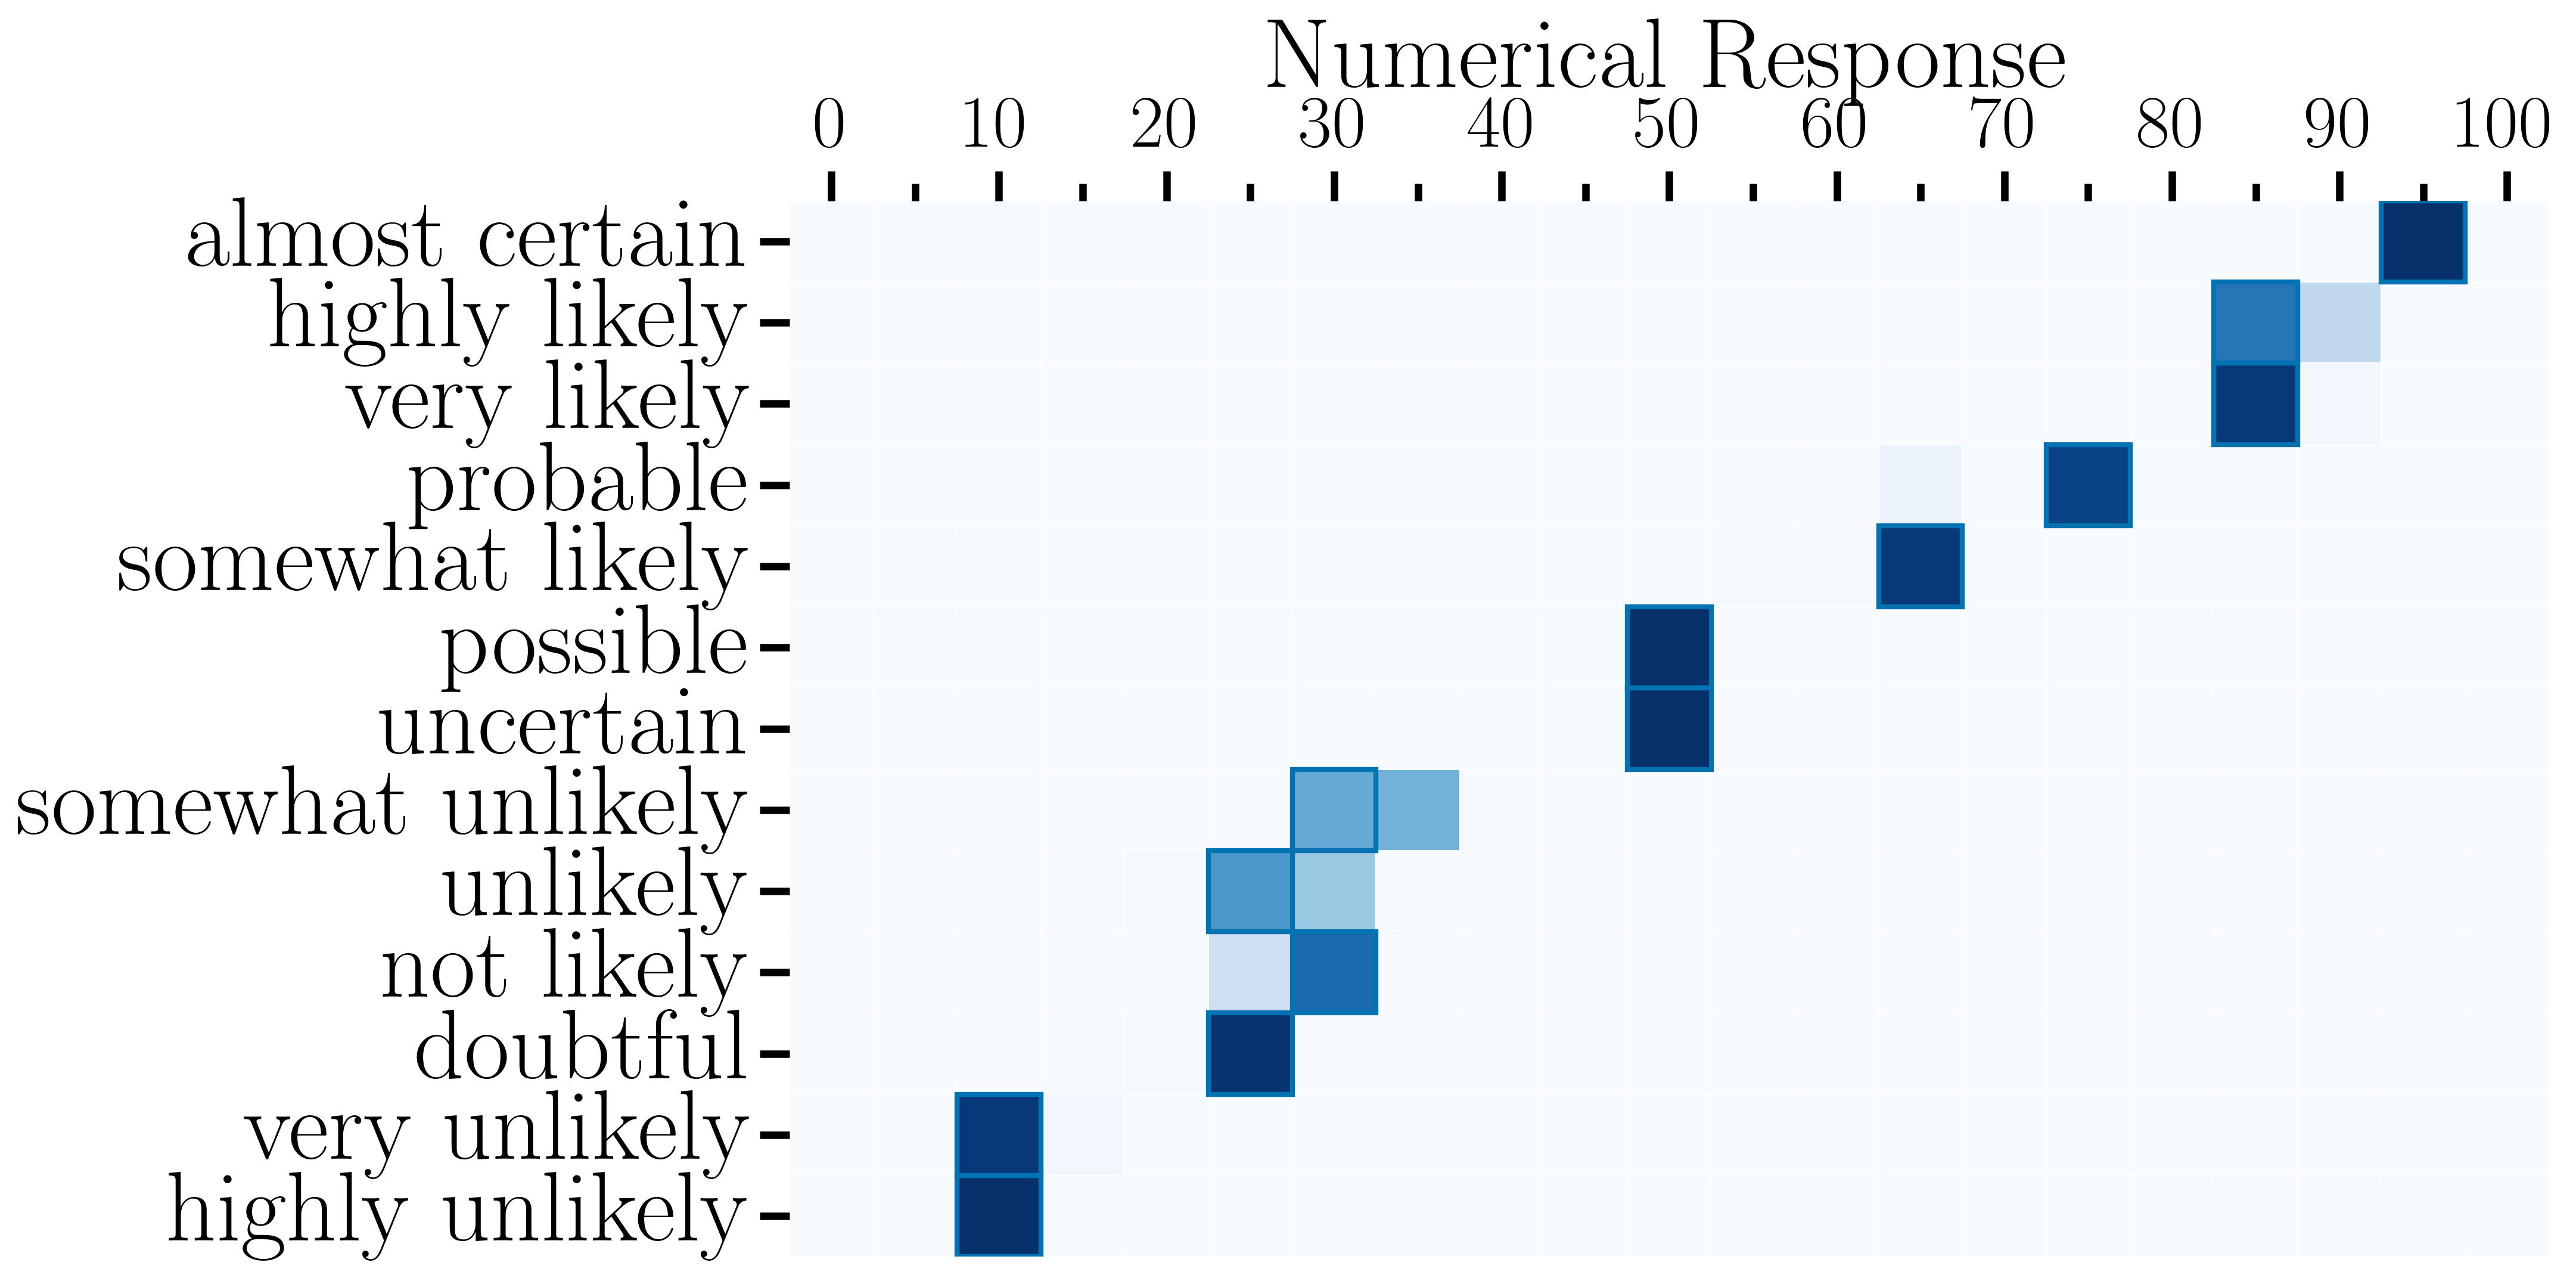

In [12]:
# presentation
cm = 1/2.54  # centimeters in inches
fig, ax= plt.subplots(1, 1, figsize=(25*cm, 15*cm), dpi=300)

heatmap = sns.heatmap(gpt4_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)
# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(gpt4_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + gpt4_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)


adjust(fig)
save_fig(fig, f"poster__all__nv_models_gpt4__normalized_2.png", **{'base_dir': '../../figures', 'dpi': 400})

/tmp/ipykernel_2022766/2363489903.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + llama_hist.index.tolist() + [""])


Saving figure at ../../figures/poster__all__nv_models_llama__normalized_2.png


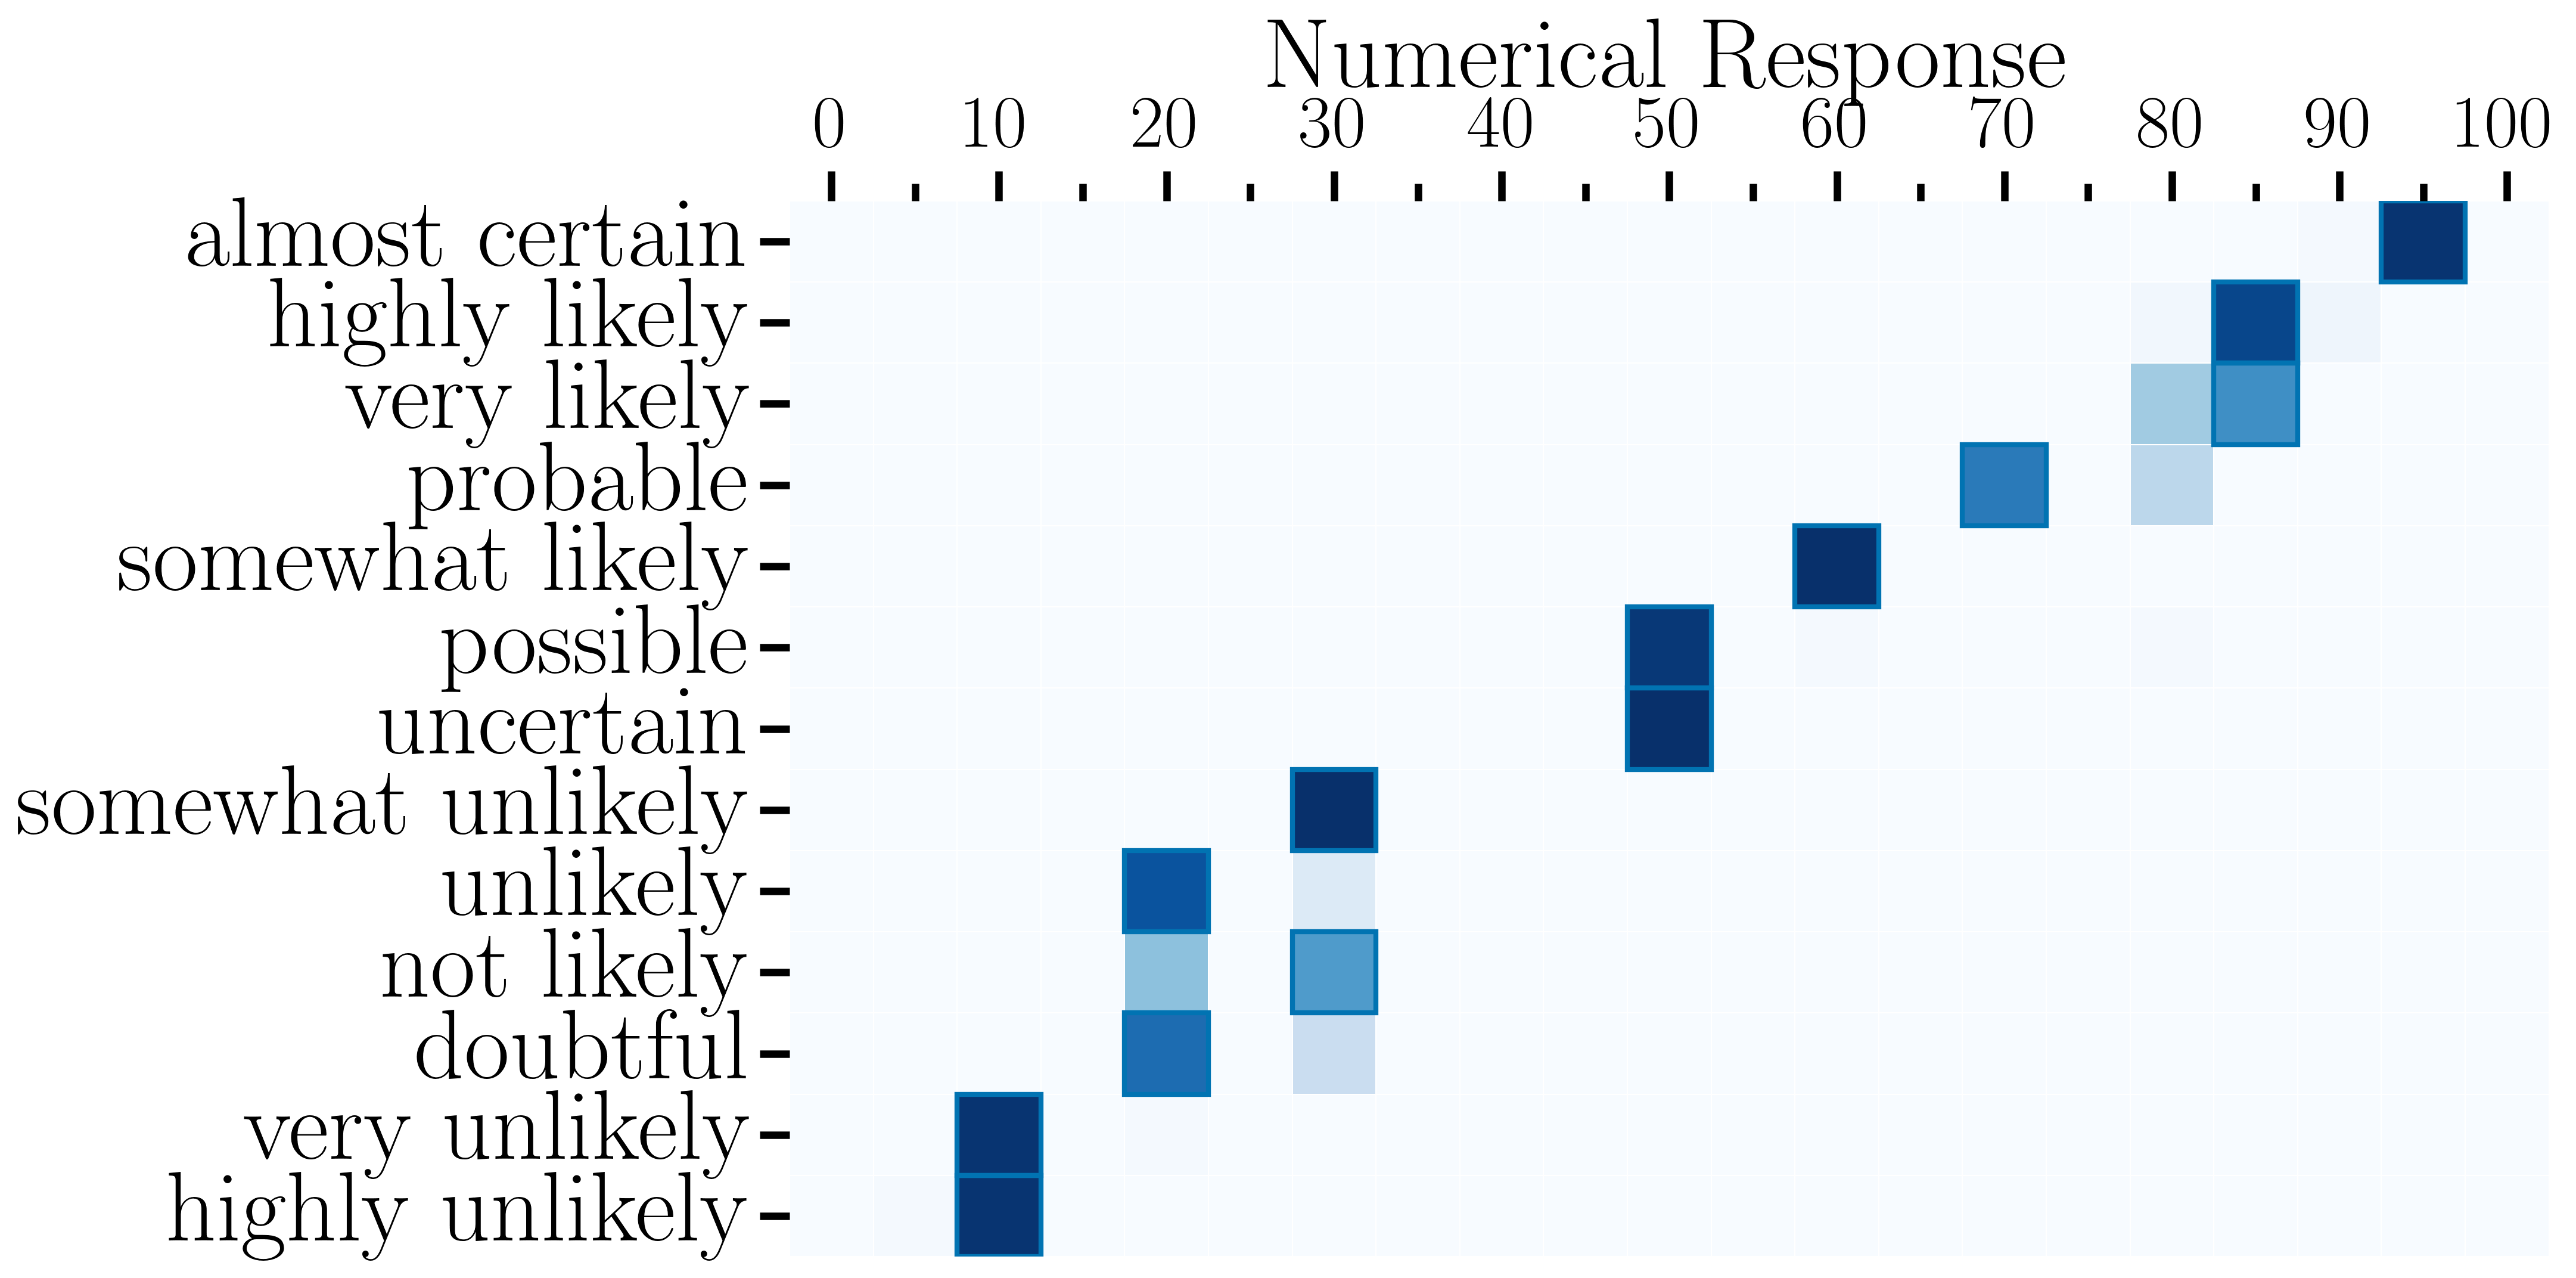

In [11]:
# presentation
cm = 1/2.54  # centimeters in inches
fig, ax= plt.subplots(1, 1, figsize=(25*cm, 15*cm), dpi=300)

heatmap = sns.heatmap(llama_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)
# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(llama_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + llama_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)


adjust(fig)
save_fig(fig, f"poster__all__nv_models_llama__normalized_2.png", **{'base_dir': '../../figures', 'dpi': 400})

/tmp/ipykernel_2022766/4230928717.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + human_hist.index.tolist() + [""])


Saving figure at ../../figures/poster__all__nv_models_human__normalized_2.png


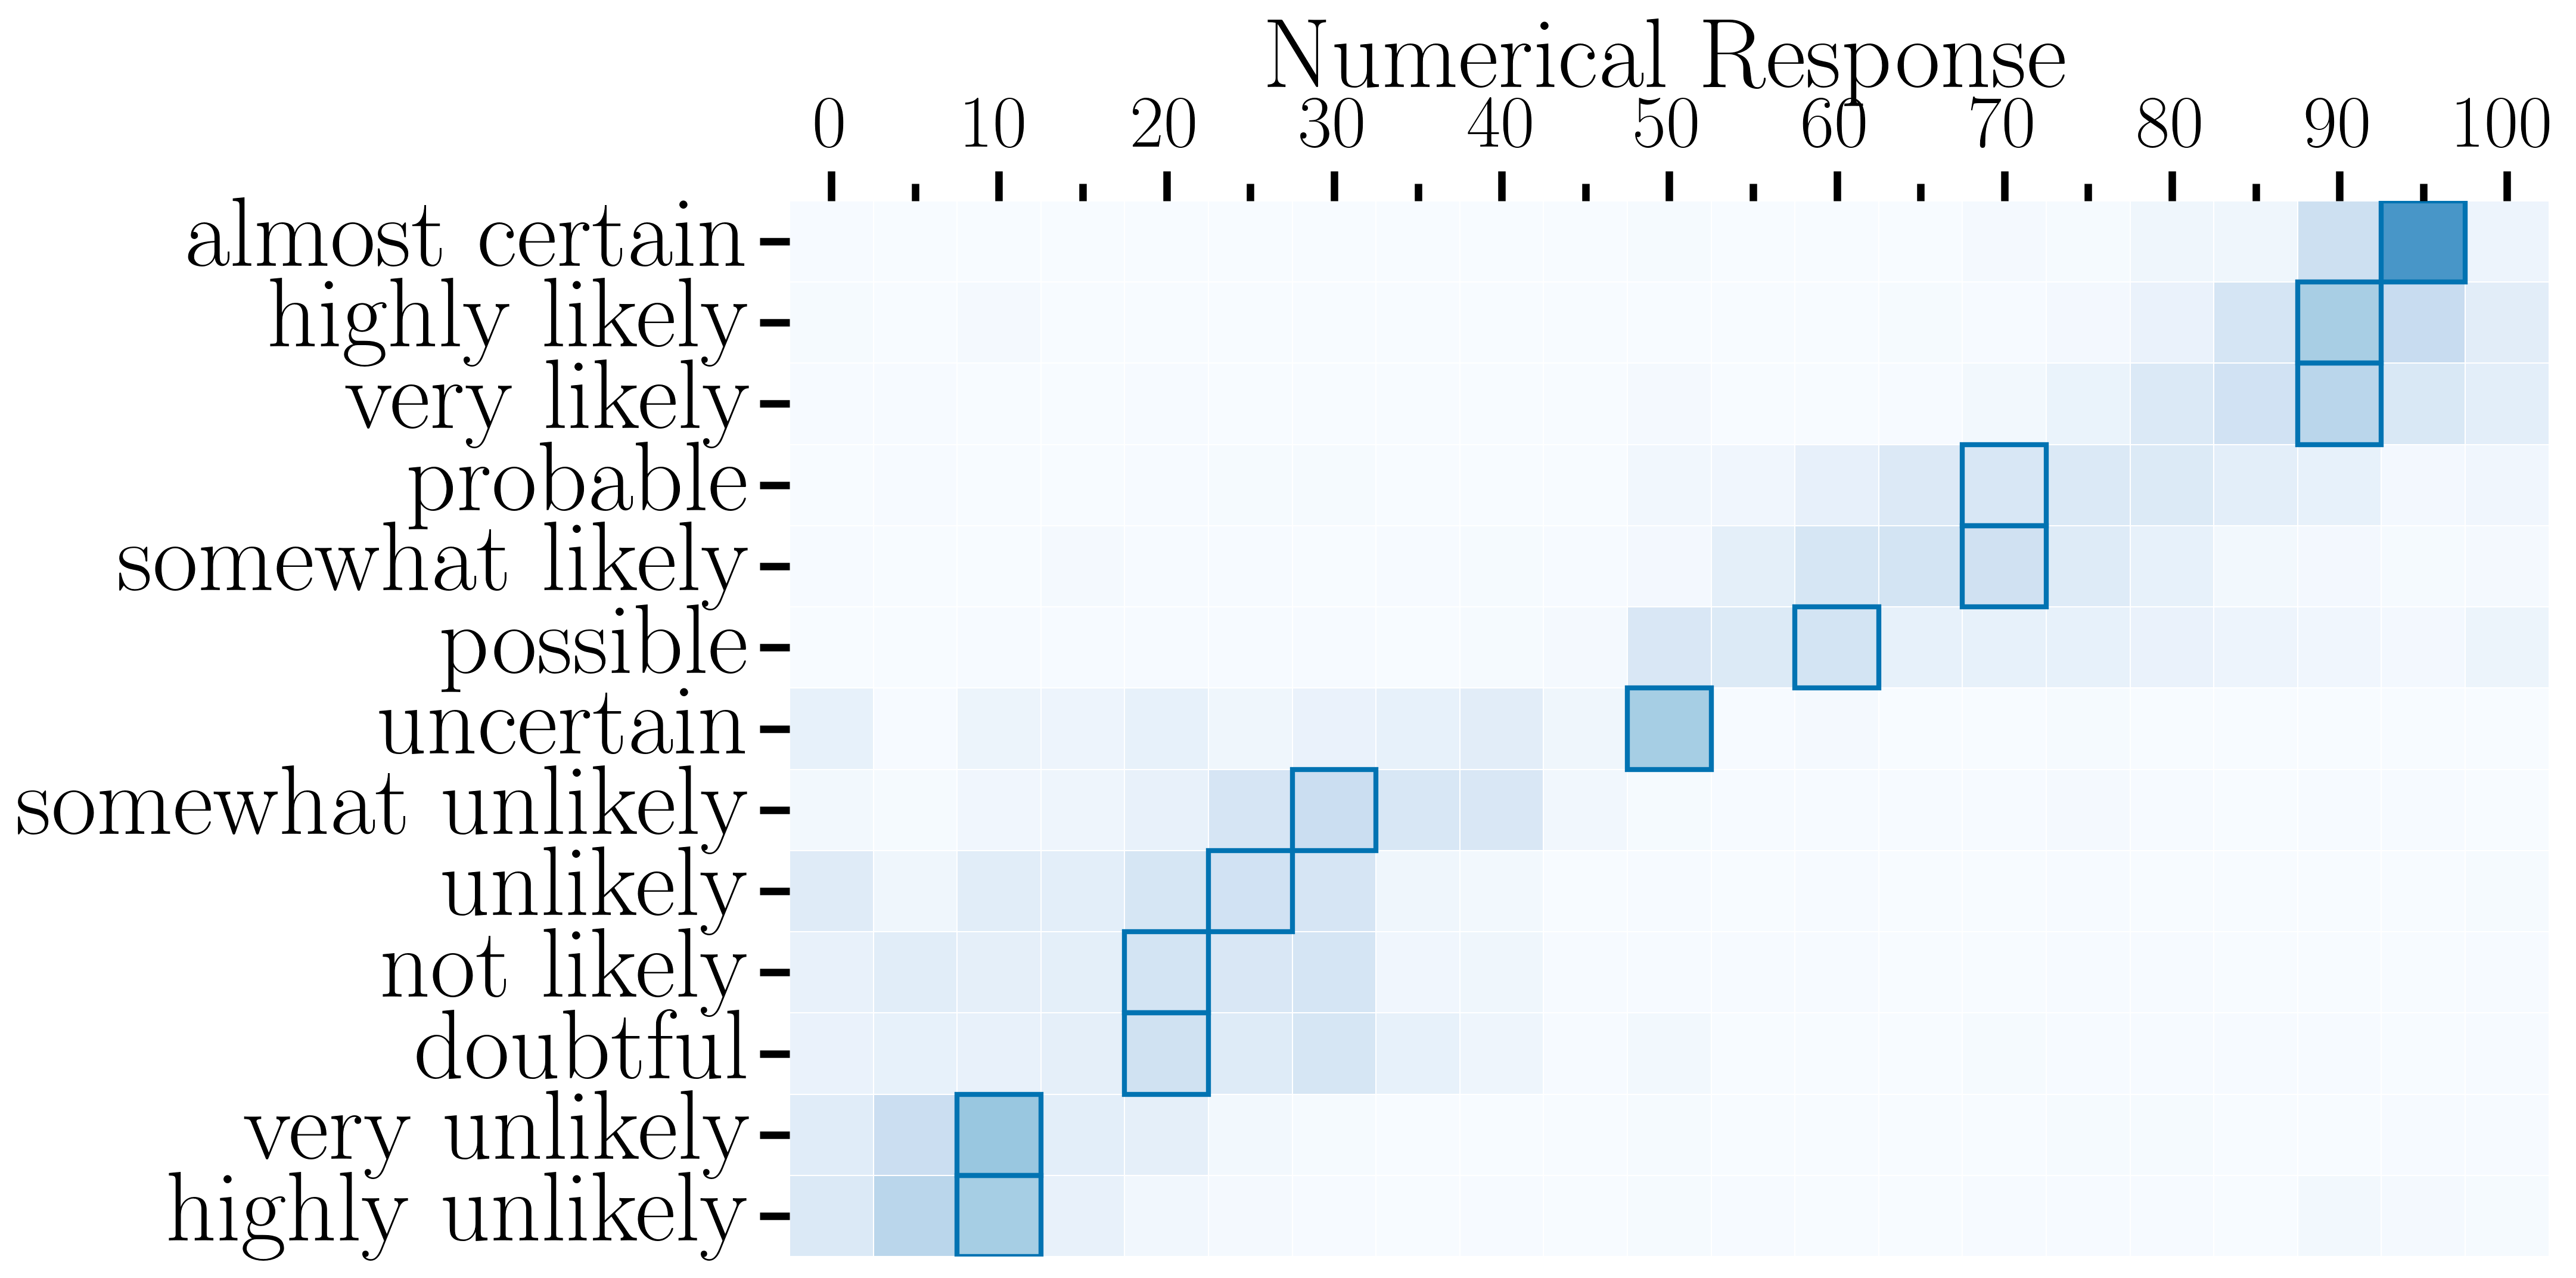

In [15]:
# presentation
cm = 1/2.54  # centimeters in inches
fig, ax= plt.subplots(1, 1, figsize=(25*cm, 15*cm), dpi=300)

heatmap = sns.heatmap(human_hist, ax=ax, **heatmap_default_kwargs, **gptfo_heatmap_kwargs)
# Add blue boxes surrounding the mode of the distribution
highlight_coords = np.argwhere(human_stats_mask == 1)    
for coord in highlight_coords:
    y, x = coord
    rect = plt.Rectangle([x, y], 1, 1, fill=False, edgecolor=sns.color_palette()[0], linewidth=2)
    ax.add_patch(rect)

# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
# Additional formatting
# --- --- --- --- --- --- --- --- --- --- --- --- --- --- ---
ax.set_xlabel("Numerical Response", fontsize=40)
ax.xaxis.set_label_position('top') 
ax.xaxis.set_minor_locator(MultipleLocator(1, offset=0.5))
ax.xaxis.set_major_locator(MultipleLocator(2, offset=0.5))

ax.set_ylabel(None)
ax.yaxis.set_major_locator(MultipleLocator(1, offset=0.5))
ax.set_yticklabels([""] + human_hist.index.tolist() + [""])

ax.tick_params(which="minor", bottom=False, left=True, top=True, width=3, length=7)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, width=3, length=12)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center", fontsize=30)
plt.setp(ax.get_yticklabels(), rotation=0, ha="right", fontsize=40)


adjust(fig)
save_fig(fig, f"poster__all__nv_models_human__normalized_2.png", **{'base_dir': '../../figures', 'dpi': 400})